In [1]:
import numpy as np
import matplotlib
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter
from scipy.stats.qmc import LatinHypercube, Sobol
from ioh import get_problem
# Plot the original 2D points in 3D
from mpl_toolkits.mplot3d import Axes3D


In [2]:
# ----------------------------
# CONSTANTS
# ----------------------------
RANDOM_SEED:int = 12349
DIMENSION = 2
N_SAMPLES = 10*DIMENSION

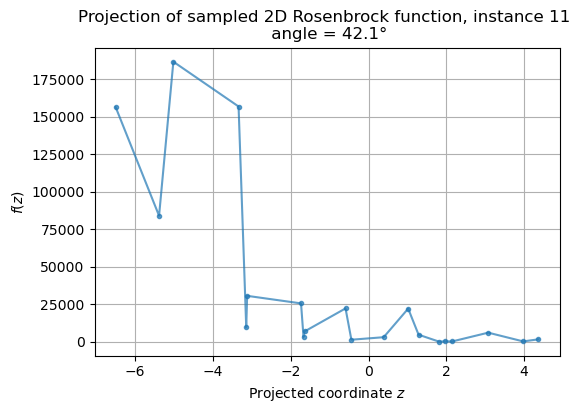

In [3]:
# -----------------------------
# 1) Sample points in 2D
# -----------------------------

rng = np.random.default_rng(seed=RANDOM_SEED)
X = LatinHypercube(d=DIMENSION, optimization="lloyd",
                   seed=RANDOM_SEED).random(N_SAMPLES) * 10 - 5  # scale to [-5, 5]

# Evaluate the problem
func = get_problem(fid=8,instance=11,dimension=2)
f = np.array(func(X))


# -----------------------------
# 3) Project 2D → 1D
# -----------------------------
# Random projection direction
u = rng.normal(loc=0,scale=1,size=2)
u /= np.linalg.norm(u)  # normalize

# Get the angle of the projection for reference
angle = np.arctan2(u[1], u[0])  # in radians
angle_deg = np.degrees(angle)

# 1D projected coordinate
t = X @ u

t_sorted = np.sort(t)
X = X[np.argsort(t),:]
f = f[np.argsort(t)]


# Make overlay projection
t_proj = t_sorted[:, None] * u

# -----------------------------
# 4) Visualization
# -----------------------------
plt.figure(figsize=(6, 4))
#plt.scatter(t, f, s=5, alpha=0.4)
plt.plot(t_sorted, f, '-o', markersize=3, alpha=0.7)
plt.xlabel("Projected coordinate $z$")
plt.ylabel("$f(z)$")

plt.title("Projection of sampled 2D {} function, instance {} \n angle = {:.1f}°".format(func.meta_data.name,func.meta_data.instance,angle_deg))
plt.grid(True)
plt.savefig("1D_projection_{}_inst{}_angle{:.1f}.pdf".format(func.meta_data.name,func.meta_data.instance,angle_deg), bbox_inches='tight')
plt.show()


In [4]:
u

array([0.74212693, 0.67025937])

C:\Users\iolar\AppData\Local\Temp\ipykernel_21004\3661865815.py:108: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.savefig("2d_surf_{}_inst{}_angle{:.1f}.pdf".format(func.meta_data.name,func.meta_data.instance,angle_deg))
c:\ProgramData\anaconda3\envs\pyflacco_3\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


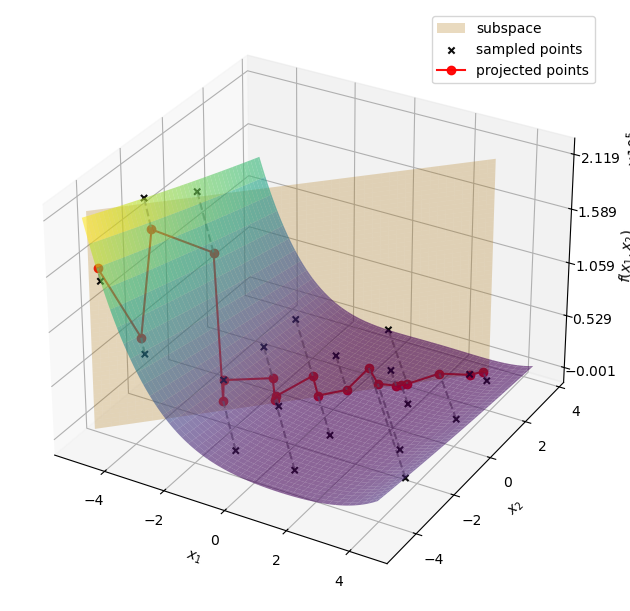

In [5]:
from scipy.interpolate import griddata


x1 = np.linspace(X[:, 0].min(), X[:, 0].max(), 501)
x2 = np.linspace(X[:, 1].min(), X[:, 1].max(), 501)
X1g, X2g = np.meshgrid(x1, x2)

#Fg = griddata(
#    points=X,
#    values=f,
#    xi=(X1g, X2g),
#    method='cubic'   # 'linear', 'nearest' also possible
#)

Fg = np.zeros(X1g.shape)

for aa in range(X1g.shape[0]):
    for bb in range(X1g.shape[1]):
        point = np.array([X1g[aa, bb], X2g[aa, bb]])
        # Find the nearest neighbor
        #distances = np.linalg.norm(X - point, axis=1)
        #nearest_index = np.argmin(distances)
        Fg[aa, bb] = func(point.tolist())

fig = plt.figure(figsize=(8, 6),  layout='constrained')
ax = fig.add_subplot(111, projection='3d')

surf = ax.plot_surface(
    X1g, X2g, Fg,
    cmap='viridis',
    edgecolor='none',
    alpha=0.6
)



ax.set_xlabel('$x_1$')
ax.set_ylabel('$x_2$')
ax.set_zlabel('$f(x_1, x_2)$')
#ax.set_title('Interpolated surface from scattered samples')
#fig.colorbar(surf, ax=ax, shrink=0.5, aspect=10)

#a, b, d = u[1], u[0], 0.0

zmin = min(Fg.min(), f.min())
zmax = max(Fg.max(), f.max())
#z = np.linspace(zmin, zmax, 50)

#if abs(b) > 1e-12:
#    x = np.linspace(X[:, 0].min(), X[:, 0].max(), 50)
#    Xg, Zg = np.meshgrid(x, z)
#    Yg = (-a * Xg - d) / b
#else:
#    # vertical plane x = const
#    y = np.linspace(X[:, 1].min(), X[:, 1].max(), 50)
#    Yg, Zg = np.meshgrid(y, z)
#    Xg = np.full_like(Yg, -d / a)

#ax.plot_surface(
#    Xg, Yg, Zg,
#    color='orange',
#    alpha=0.3
#)

t_vals = np.linspace(t_proj.min()*1.4, t_proj.max()*1.4, 50)
z_vals = np.linspace(zmin, zmax, 50)

T, Z = np.meshgrid(t_vals, z_vals)

X_plane = u[0] * T
Y_plane = u[1] * T

ax.plot_surface(
    X_plane,
    Y_plane,
    Z,
    color='orange',
    alpha=0.25,
    label="subspace"
)

ax.scatter(X[:, 0], X[:, 1], f, c='black', marker='x', alpha=0.95, label="sampled points")
ax.plot(t_proj[:,0],t_proj[:,1], f, c='red', marker='o', alpha= 0.95, linestyle="-", label="projected points")

for i in range(len(X)):
    ax.plot(
        [X[i,0], t_proj[i,0]],
        [X[i,1], t_proj[i,1]],
        [f[i],     f[i]],
        color='grey',
        linestyle='--',
        alpha=0.8,

    )

fmt = ScalarFormatter(useMathText=True)
fmt.set_scientific(True)
fmt.set_powerlimits((0, 5))

ax.zaxis.set_major_formatter(fmt)
ax.zaxis.get_offset_text().set_visible(True)

ax.set_zticks(np.linspace(zmin, zmax, 5))
#fig.subplots_adjust(left=0.05, right=0.75, bottom=0.05, top=0.95)
ax.set_zlabel('$f(x_1, x_2)$', labelpad=5)

ax.legend()
plt.savefig("2d_surf_{}_inst{}_angle{:.1f}.pdf".format(func.meta_data.name,func.meta_data.instance,angle_deg))
plt.show()